In [1]:
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torchvision import transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
from transformers import CLIPTokenizer, CLIPTextModel
import random

from noise_schedule import NoiseSchedule
from u_net import UNet
from flower_dataset import FlowerDataset

c:\Users\lolan\Desktop\projects\text-to-image-generator\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch.Size([4, 128])


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
image_size = 64
batch_size = 16
epochs = 200
timesteps = 1000
lr = 2e-4

In [3]:
image_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2 - 1)
])

clip_tokenizer = CLIPTokenizer.from_pretrained('openai/clip-vit-base-patch32')
clip_text_model = CLIPTextModel.from_pretrained('openai/clip-vit-base-patch32').to(device)
clip_text_model.eval()
for param in clip_text_model.parameters():
    param.requires_grad = False

Loading weights: 100%|██████████| 196/196 [00:00<00:00, 36841.61it/s]
[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...1

In [4]:
dataset = FlowerDataset(
    annotations='../captions.csv',
    img_dir='../images/train',
    image_transform=image_transform,
    caption_transform=None, # for now
)

In [5]:
dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

In [6]:
schedule = NoiseSchedule(timesteps=timesteps, device=device)
model = UNet(in_channels=3, base_channels=64).to(device)
model.load_state_dict(torch.load('unet_checkpoint.pt'))
optimizer = AdamW(model.parameters(), lr=lr)
loss_fn = torch.nn.MSELoss()

In [7]:
@torch.no_grad()
def sample(model, schedule, prompt, image_size=64, batch_size=4, channels=3, device='cpu', guidance_scale=7.5):
    model.eval()

    text_embed = encode_captions([prompt] * batch_size, clip_tokenizer, clip_text_model, device)
    null_embed = encode_captions([""] * batch_size, clip_tokenizer, clip_text_model, device)  # empty prompt

    x = torch.randn(batch_size, channels, image_size, image_size, device=device)
    for t_step in reversed(range(schedule.timesteps)):
        t = torch.full((batch_size,), t_step, device=device, dtype=torch.long)

        predicted_noise_cond = model(x, t, text_embed)
        predicted_noise_uncond = model(x, t, null_embed)
        predicted_noise = predicted_noise_uncond + guidance_scale * (predicted_noise_cond - predicted_noise_uncond)

        alpha = schedule.alphas[t_step]
        alpha_bar = schedule.alphas_cumprod[t_step]
        beta = schedule.betas[t_step]

        noise = torch.randn_like(x) if t_step > 0 else torch.zeros_like(x)
        x = (1 / torch.sqrt(alpha)) * (
            x - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * predicted_noise
        ) + torch.sqrt(beta) * noise

    model.train()
    return x
#samples = sample(model, schedule, prompt="a red rose in bloom", batch_size=4, device=device)

In [8]:
@torch.no_grad()
def encode_captions(captions, tokenizer, text_model, device, max_length=32):
    tokens = tokenizer(
        list(captions), padding='max_length', truncation=True,
        max_length=max_length, return_tensors='pt'
    ).to(device)

    output = text_model(**tokens)
    return output.last_hidden_state

In [18]:
for epoch in range(epochs):
    epoch_loss = 0.0
    progress = tqdm(dataloader, desc=f'Epoch {epoch+1}/{epochs}')

    for captions, images in progress:
        images = images.to(device)
        batch_size_actual = images.shape[0]

        captions = [c if random.random() > 0.1 else "" for c in captions]  # 10% dropout
        text_embed = encode_captions(captions, clip_tokenizer, clip_text_model, device)

        t = torch.randint(0, timesteps, (batch_size_actual,), device=device)
        x_t, noise = schedule.add_noise(images, t)

        predicted_noise = model(x_t, t, text_embed)

        loss = loss_fn(predicted_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress.set_postfix(loss=loss.item())

    '''
    if (epoch + 1) % 10 == 0:
        samples = sample(model, schedule, prompt, batch_size=4, device=device)
        samples_display = (samples.clamp(-1, 1) + 1) / 2
        fig, axes = plt.subplots(1, 4, figsize=(12, 3))
        for i in range(4):
            axes[i].imshow(samples_display[i].permute(1, 2, 0).cpu().numpy())
            axes[i].axis("off")
        plt.suptitle(f"Epoch {epoch+1}")
        plt.show()
    '''
    avg_loss = epoch_loss / len(dataloader)
    print(f'Epoch {epoch+1} average loss is {avg_loss:.4f}')

    torch.save(model.state_dict(), 'unet_checkpoint.pt')

Epoch 1/200: 100%|██████████| 172/172 [00:12<00:00, 13.91it/s, loss=0.0064] 


Epoch 1 average loss is 0.0297


Epoch 2/200: 100%|██████████| 172/172 [00:11<00:00, 14.83it/s, loss=0.0123] 


Epoch 2 average loss is 0.0318


Epoch 3/200: 100%|██████████| 172/172 [00:10<00:00, 15.97it/s, loss=0.014]  


...

Epoch 198 average loss is 0.0289


Epoch 199/200: 100%|██████████| 172/172 [00:11<00:00, 15.56it/s, loss=0.0855] 


Epoch 199 average loss is 0.0292


Epoch 200/200: 100%|██████████| 172/172 [00:10<00:00, 15.99it/s, loss=0.029]  

Epoch 200 average loss is 0.0288


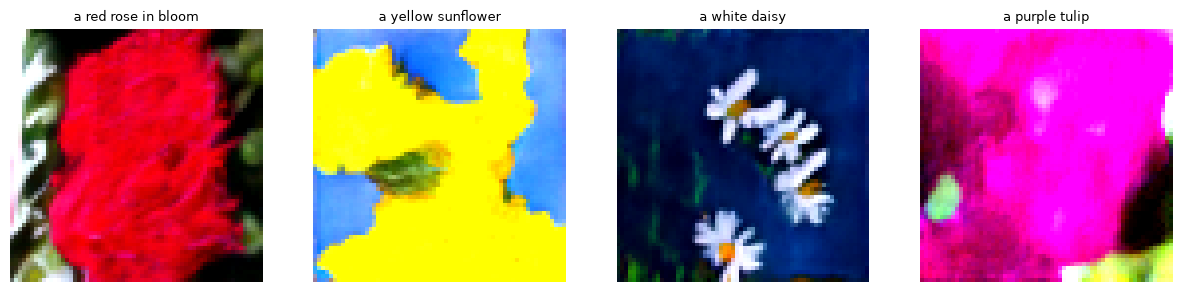

In [9]:
prompts = [
    "a red rose in bloom",
    "a yellow sunflower",
    "a white daisy",
    "a purple tulip",
]

fig, axes = plt.subplots(1, len(prompts), figsize=(15, 4))
for i, prompt in enumerate(prompts):
    samples = sample(model, schedule, prompt=prompt, batch_size=1, device=device, guidance_scale=7.5)
    img = ((samples[0].clamp(-1, 1) + 1) / 2).permute(1, 2, 0).cpu().numpy()
    axes[i].imshow(img)
    axes[i].set_title(prompt, fontsize=9)
    axes[i].axis("off")
plt.show()